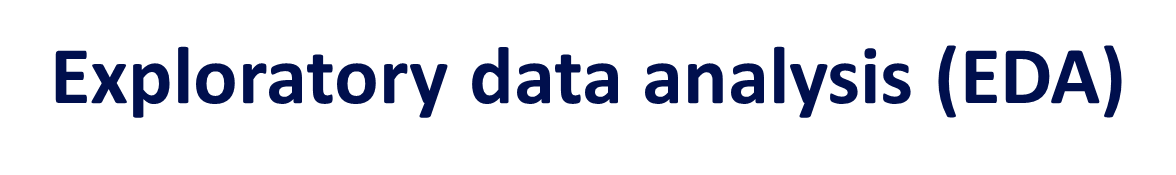

# **Data Visualisation with Pandas: the Pokemon dataset**

![pokemon](https://blondegeography.wordpress.com/wp-content/uploads/2016/07/pokeomon.jpg)

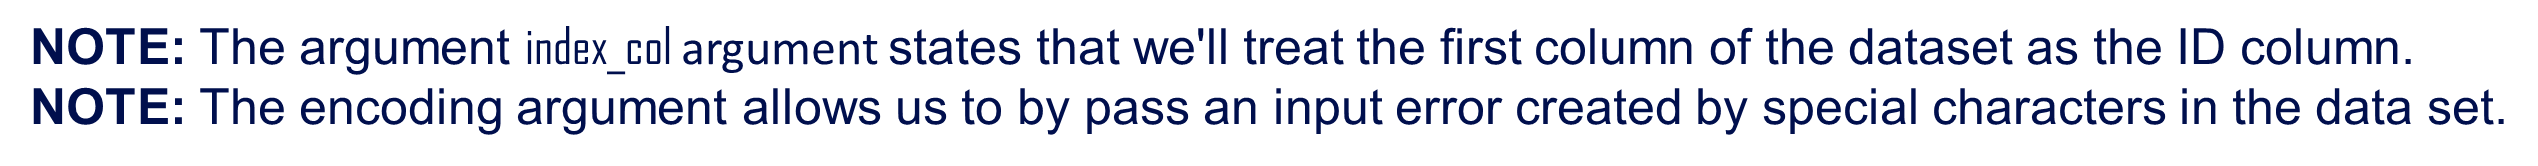

[Character encoding](https://www.w3schools.com/html/html_charset.asp)

**Libraries used for EDA:**

1. **Matplotlib**: is a foundational Python library for creating static, animated, and interactive visualizations. It’s highly customizable and works well for everything from simple plots to complex figure layouts.
2. **Seaborn**: is a Python data visualization library built on top of matplotlib. It’s designed to make statistical plots more attractive, informative, and easier to create — especially for data scientists, educators, and researchers. Seaborn offers a rich variety of built-in color palettes like 'deep', 'muted', 'pastel', and 'dark', making it easy to create visually appealing and thematically consistent plots with just a single line of code.
You can learn about it more [here](https://seaborn.pydata.org/)


# **Section 1 Understanding Your Data**

In this section you get basic information about your data:
1. How big is it?
2. What is the dataset about? Try to get as much information from the data webiste/source as possible?
3. What type of features you have (discrete data (e.g. 1,2,3), Continuous varialbes (e.g. 1.4, 2.3, 3.5. etc.), categorical data (e.g. Male, Female)



In [ ]:
#Import the basic libraries needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a useful library for Data Visualisation
from scipy.stats import skewnorm

In [ ]:
# Upload the pokeman.csv and open it with the right encoding. There are other types of encoding but the most common is UTF-8
df = pd.read_csv('./pokemon.csv',index_col=False, encoding='ISO-8859-1')

df.head(5)

In [ ]:
#Get the length of the data (how many rows)
len(df)

In [ ]:
#Get basic information about your dataset of Pokemons. Does any of the information make sense to you? You need to learn about Pokemons a bit to be understand it.
df.info()

In [ ]:
# What is the difference between .describe()  and .info(). Check the output here and you will know
df.describe()

**As part of EDA, I may need to get information about a particular column/feature. For example, I need to know how many generations of Pokemon does my data have. Also, how many instances in each generation. This is done by the function .value_counts()**

In [ ]:
# How many pokemon generations we have and the frequency of each

df["generation"].value_counts()

**I would also need to know what are the columns/features I have in my data**

In [ ]:
# colums represent our attributes
df.columns

In [ ]:
#How many of my Pokemons is legendary

df["is_legendary"].value_counts()

**Important information to get is the types of attributes I have. Check what types of data in Pandas from Lab 2**

In [ ]:
df.dtypes

# **Section2: Data Visualisation**

You can use simple tools such as the histogram, boxplot, or bar chart to visualize the
variations in the values of one column of a dataset across the populations of the data
object. Numerical and categorical attributes require different tools for each type of attribute.
<mark>**For numerical attributes**</mark>, we can use either the **histogram or boxplot** to summarize the attribute, whereas <mark>**for categorical attributes**</mark>, it is best to use **bar charts**. The following examples walk you through how this can be done all at once for any dataset.

**Remember:** The **figure()** is a matplotlib function used to plot the figures. The figsize is used to set the size of the figure.

For example, `plt.figure(figsize =(12, 3))` changes the horizontal and vertical width of the figure in inches

# **1. Visualisation of numerical data**

## **Histograms:**
Histogram plots are used to depict the distribution of any **continuous variable**. For example, the weight of the Pokemon. Check it out.

In [ ]:
df['weight_kg']

**In order to decide which graph I will use with which attributes, I would need to know if it is discrete, continuous, or categorical. The following function can be used for this purpose:**

In [ ]:
# Getting the continous attriburtes using the dtypes function keys and values
df.info()

In [ ]:
# I will chose last continous variable 'weight_kg' to visualise by a histogram. This is how I create a histogram in matplotlib.

g=plt.hist(df['weight_kg'], histtype='bar', ec='black')
g=plt.xlabel('Pokemon weight')
g=plt.ylabel('Frequency')
g=plt.title('weight')
# Remember to save the file before the .show() function. If you swap the order the image will be saved as a blank figure

# plt.savefig('foo.png', bbox_inches='tight') # I can specify the parameters of this saved figure and delete white spaces around the image
# plt.savefig('foo.pdf')
plt.show()


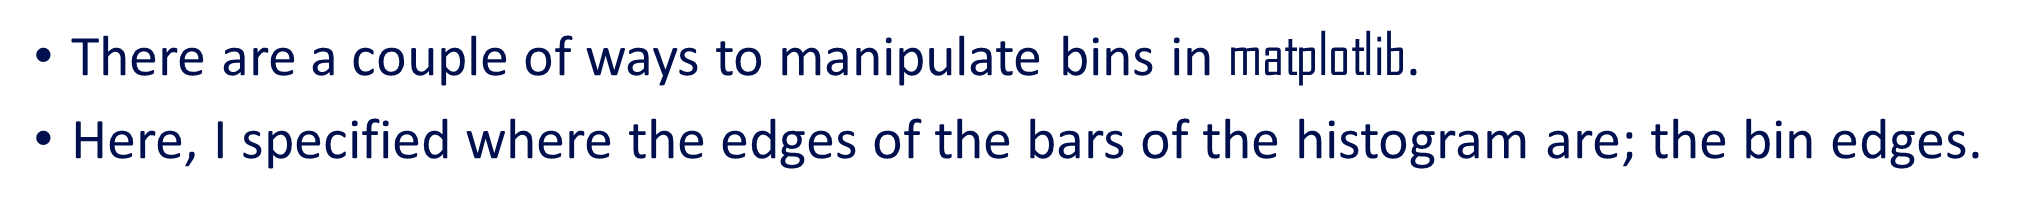

In [ ]:
# Here is a historgram of speed, another continuous variable. I have the edges to be black and I change the number of bins to have a good represetation

bin_edges = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150]
plt.hist(df['speed'], histtype='bar', edgecolor='black', bins=bin_edges)

plt.xlabel('Pokemon Speed')
plt.ylabel('Frequency')
plt.title('Speed')
plt.show()


In [ ]:
# I can also have a neat purple color with the color parameter

plt.hist(df['speed'], histtype='bar', edgecolor='purple', bins=20, color = "pink",lw = 2) #lw = line width
plt.xlabel('Pokemon Speed',color = "purple")
plt.ylabel('Frequency',color = "purple")
plt.title('Speed', color = "purple")
plt.show()

In [ ]:
# I can play with the colors and bins
df.hist(column = "speed",lw=2,edgecolor='purple',ec="purple",color="pink")

**You can find other ways to change the [histogram](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)**

## **Distplot**

 Distribution plot, depicts the variation in the data distribution. Seaborn Distplot represents the overall distribution of **continuous** data variables.



In [ ]:
# I will use seaborn to draw a distplot to the speed


# Updated distribution plot for speed
sns.histplot(data=df, x='speed', kde=True, color='steelblue')

plt.title('Distribution of Speed')
plt.xlabel('Speed')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##  **Boxplot**
- Boxplot Highlights median, quartiles, and outliers. Ideal for comparing groups. More on it [here](https://guideofgreece.com/)
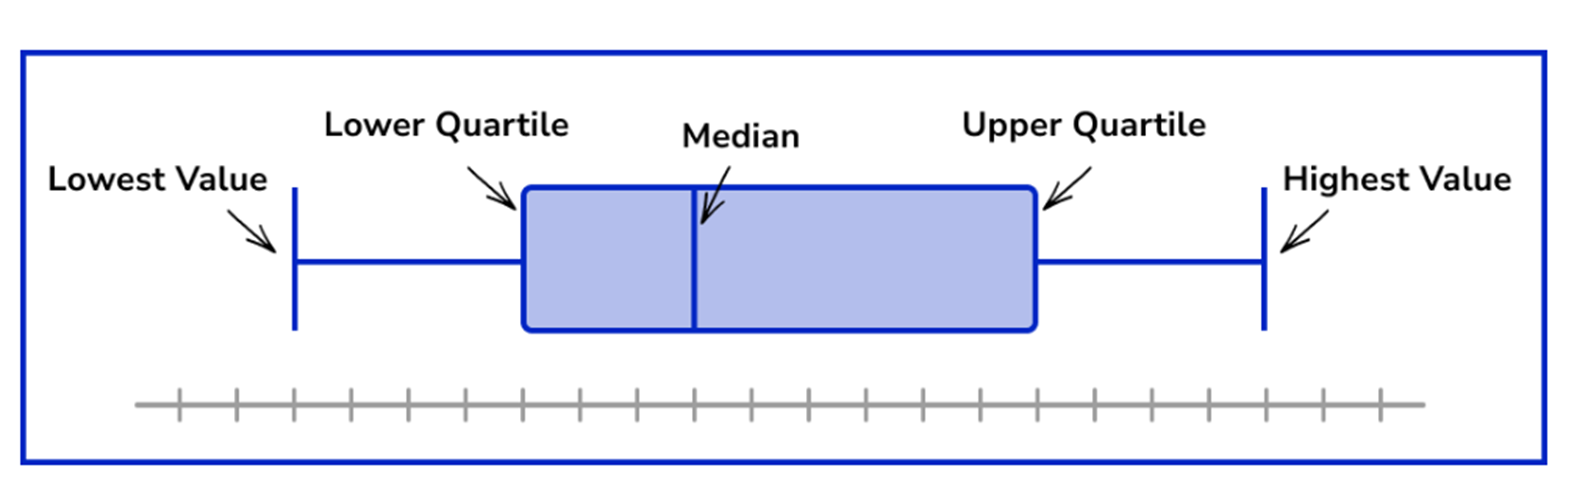

**I will compare the pokeomon's 'attack', 'speed', 'sp_defense' with box plots**

In [ ]:

# Select the relevant numerical columns
columns_to_plot = ['attack', 'speed', 'sp_defense']
data = df[columns_to_plot]

# Create the box plots
plt.figure(figsize=(8, 6))
plt.boxplot([data[col] for col in columns_to_plot], labels=columns_to_plot, patch_artist=True)

# Optional: Customize colors and add mean overlay
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(plt.gca().artists, colors):
    patch.set_facecolor(color)



plt.title('Box Plots of Attack, Speed, and Speed of Defense')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Compare with box plots. I will compare using Seaborn in one line between the generation of the Pokemon and his speed**

In [ ]:
# I can compare between generation and speed

sns.boxplot(x="generation",y="speed",data=df)
plt.show()

**Do you see any outliers?**

In [ ]:
# I can plot several numerical attributes together to get an understanding of my data. Here I use histogram and boxplot together
numerical_attributes = ['attack', 'speed', 'sp_defense']
for att in numerical_attributes:
  plt.subplot(2,1,1)
  df[att].plot.hist()
  plt.subplot(2,1,2)
  df[att].plot.box(vert=False)
  plt.tight_layout()
  plt.show()
  # plt.savefig('{}.png'.format(att), dpi=600)

# **2. Visualisation of categorical data**

## **Bar charts**
This is one of the most common types of visualization that almost everyone must have
encountered. Bars can be drawn horizontally or vertically to represent categorical
variables. We will use the same function used above to see which of our attributes are categorical (it will have 'object' as a data type in pandas

In [ ]:
df.info()

In [ ]:
# Let's check type 1 Pokemon

df['type1'].value_counts()

In [ ]:
# Bar chart for type 1 Pokemon

type_counts = df['type1'].value_counts()

# Create the bar chart
plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Frequency of Pokémon Type1')
plt.xlabel('Type1')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**What do you interpret from the bar chart of type 1?**

**I can also use seaborn to get a bar chart. Which one do you think is more appealing?**

In [ ]:
import warnings  # stop the warnings
warnings.filterwarnings('ignore')
# make the figure bigger
plt.figure(figsize=(10,8))
sns.countplot(x='type1', data=df, palette='Accent') # choose the colors
plt.xticks(rotation=45)  # change the rotation of the x labels

In [ ]:
# Visualisation of categorical data with bar charts


# Count frequencies
type1_counts = df['type1'].value_counts()
type2_counts = df['type2'].value_counts()

# Combine into a DataFrame, I can fill null values also.
type_df = pd.DataFrame({
    'Type1': type1_counts,
    'Type2': type2_counts
}).fillna(0)

# Sort by total frequency for clarity
type_df['Total'] = type_df['Type1'] + type_df['Type2']
type_df = type_df.sort_values('Total', ascending=True)

# Plot grouped horizontal bars
plt.figure(figsize=(10, 8))
bar_width = 0.4
indices = np.arange(len(type_df))

plt.barh(indices, type_df['Type1'], height=bar_width, color='skyblue', label='Type1', edgecolor='black')
plt.barh(indices + bar_width, type_df['Type2'], height=bar_width, color='lightgreen', label='Type2', edgecolor='black')

plt.yticks(indices + bar_width / 2, type_df.index)
plt.xlabel('Count')
plt.title('Frequency of Pokémon Type1 and Type2')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



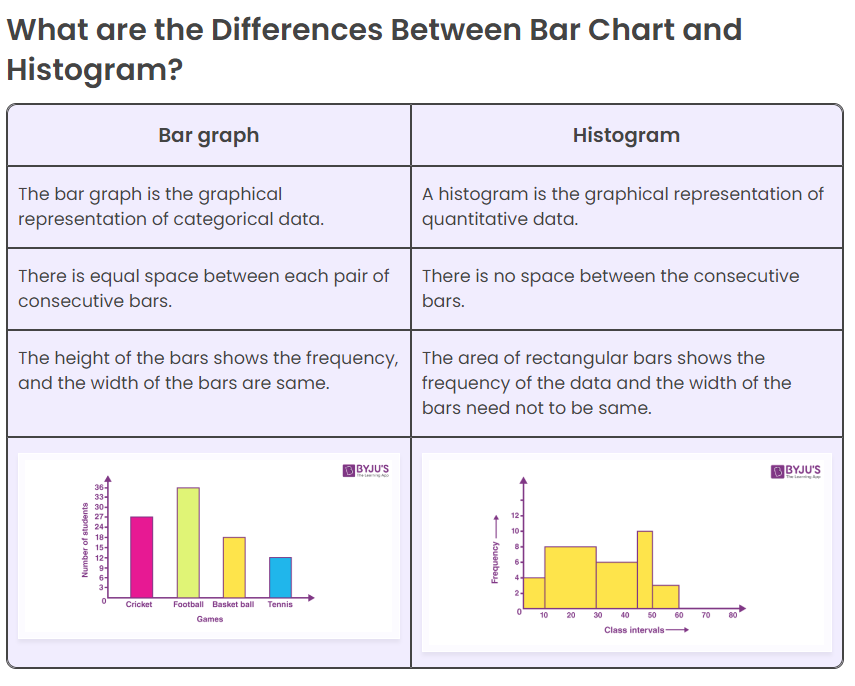

## **Pie Charts**

**Good Practice Advice**

Technically, you could also use a pie chart to summarize a categorical attribute. However, if you have too many attributes it would not very well presented. Compare the following graphs

In [ ]:
#  Compare these two graphs

dfsmall = pd.DataFrame({'mass': [0.330, 4.87 , 5.97],
                   'radius': [2439.7, 6051.8, 6378.1]},
                  index=['Mercury', 'Venus', 'Earth'])
plot = dfsmall.plot.pie(y='mass', figsize=(5, 5))


**If I pie chart type1 however, it will be very noisy. A barchart in that case would be a better visualisation**

In [ ]:
df.groupby('type1').size().plot(kind='pie', autopct='%.2f')

# **3. Comparing Data for relationships, correlations and trends**


## **Graphs for Bivariate Numerical Data**

These reveal relationships, correlations, and trends. Let's find the relationship between the weight and the height of the Pokemon.

**Scatter Plot**
Scatter plots are also called scatter graphs, scatter charts, scattergrams, and scatter
diagrams. It shows the type of corelationship between variables

When should we use a scatter plot? Scatter plots can be constructed in the following two
situations:


*   When one continuous variable is dependent on another variable, which is under the control of the observer

*  When both continuous variables are independent


Lets see for example a scatterplot of the hight and weight of the Pokeomon both are continuous variables


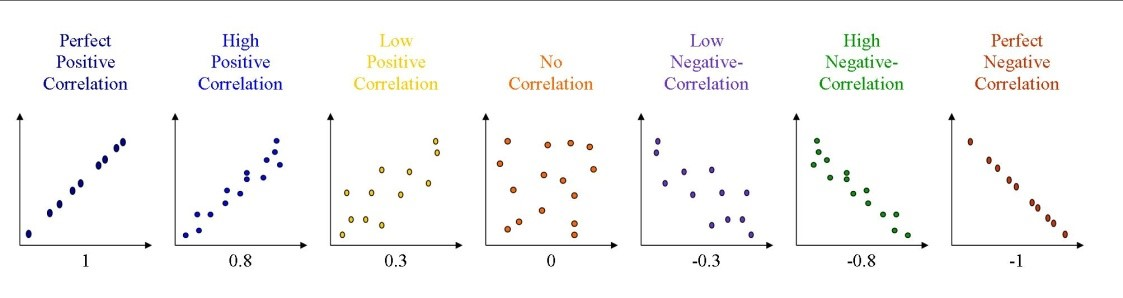

**Types of Correlation**

| Type               | Description                                                                 | Example                            |
|--------------------|-----------------------------------------------------------------------------|------------------------------------|
| **Positive Correlation** | As one variable increases, the other also increases.                          | Height vs. weight in humans        |
| **Negative Correlation** | As one variable increases, the other decreases.                          | Exercise time vs. body fat         |
| **Zero (No) Correlation** | No consistent relationship between the variables.                        | Shoe size vs. exam scores          |
| **Perfect Correlation**   | A theoretical case where variables move in exact sync (±1 correlation). | Ideal linear relationships         |
| **Nonlinear Correlation** | Variables are related, but not in a straight line.                       | Stress vs. performance (inverted U)|


In [ ]:
# I am using Seaborn here for the scatterplot


# Create the scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='weight_kg', y='height_m', color='teal', edgecolor='black', alpha=0.7)
sns.regplot(data=df, x='weight_kg', y='height_m', scatter=False, color='darkred', line_kws={'label':"Linear Fit"})

plt.title('Scatter Plot of Weight vs. Height')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



**Comparing two attributes with the Hue function in seaborn makes it more visible**

I will take a slice of the data to make it easier in graphs.

In [ ]:
#make the data set smaller

df_small = df[['against_dragon','speed','attack','defense','generation']]

In [ ]:
df_small.head()


**Create a scatter plot between the defense speed and the attack speed for pokemons without the hue function**

In [ ]:
# Compare without the hue function
sns.lmplot(x='attack', y='defense', data =df_small, fit_reg=True)

**Now let's use the hue function by giving a color to each generation of the pokemons**

In [ ]:
sns.lmplot(x='attack',y='speed', data=df, fit_reg=False, hue='generation')

**Let's gets only the scatter plot for generations that are 3 and above**

In [ ]:
df_gen1 = df_small[df['generation'] >=3]

In [ ]:
sns.lmplot(x='attack',y='speed', data=df_gen1, fit_reg=False, hue='generation')

**Catplot**

A catplot in Seaborn is a versatile figure-level function for visualizing categorical data. It acts as a wrapper that can generate several types of plots — like bar plots, box plots, violin plots, and strip plots — depending on the kind parameter.

- It is Flexible: You can switch between plot types using kind='bar', 'box', 'violin', 'strip', 'swarm', etc.
Here I am using the 'swarm' to compare all generations speeds


In [ ]:
#Factor Plots: Make it easy to separate plots by categorical classes.

g =sns.catplot(x='against_dragon',
                  y='speed',
                  hue='generation', #Hue means color the plot by the generation features
                  col='generation', #col= means spearate by generation
                  data=df_small,
                  kind='swarm') #kind is a swarmplot
g.set_xticklabels(rotation=45) #Rotate the axis on the x-ticks by 45-degrees

## **Graphs for relationship between categorical data**

The best visual tool for examining the relationship between two categorical attributes is the color-coded contingency table or a `heatmap`. A contingency table is a matrix that shows the frequency of data objects in all the possible value combinations of two attributes.

**Cross Table**

**Let's compare type 1 and type 2 with cross tablet**

In [ ]:
pd.crosstab(df.type1, df.type2)

## **Heatmaps**

**Generally, heatmaps are best suited for datasets where you can represent values as colors, typically continuous or discrete numerical data. However, you can also use them for categorical data that has been quantified or summarized (e.g., counts, averages)**.

<mark>Note

If the dataset contains extreme outliers or is very sparse, a heatmap might not be as effective without preprocessing or normalization.

In [ ]:
df_small.head()

In [ ]:
# Select specific columns from the Pokémon dataset
selected_columns = df[['against_dragon','speed','attack','defense','generation']]


sns.heatmap(selected_columns.corr(),annot=True)

In [ ]:
sns.heatmap(df_small.corr(), cmap='RdYlGn_r', linewidths=0.5, annot=True)

In the heatmap, a **coefficient close to 1 means that there's a very strong positive correlation** between the two
variables. The diagonal line is the correlation of the variables to themselves – so they'll, of
course, be 1.

# **Comparing categorical and numerical variables**

To compare numerical and categorical variables, you're essentially asking: How does a numerical feature vary across different categories? This is a core concept in exploratory data analysis and teaching students about group-level patterns. Here’s how to approach


**Box Plot**

It compares Distribution, median, outliers per group. I will use it to compare the attack, against dragon and the generation of each pokemon

In [ ]:
import warnings  # stop the warnings
warnings.filterwarnings('ignore')
plt.figure(figsize =(12, 10))
sns.boxplot(data=df_gen1, x="against_dragon", y="attack", hue="generation")

**Can you deduce anything from the spreakd of the distribution?**

**Violin Plot**

**Distribution shape + density**

In [ ]:
sns.violinplot(x="generation", y="attack", data=df_small, palette="Set2")

